# DS4FE — Skew Dynamics from the Reconstructed IV Surface

We now have 523 daily SPX surfaces on a fixed 7×9 grid (`data/iv/surfaces.parquet`). This notebook asks three questions of that panel:

1. **Smile features** — extract the level / skew / curvature of the smile per tenor, per day. This turns the surface into the classic "volatility skew" time series.
2. **Sticky strike vs sticky delta** — when the underlying moves, does the smile stay put in strike space or float with the forward? Measured by the **skew-stickiness ratio (SSR)** per tenor.
3. **PCA vs ISOMAP** — is the surface manifold really just 3 linear factors (level / term / skew, as in Cont & da Fonseca 2002), or is there nonlinear structure (level–skew coupling, regime hysteresis) that a manifold method sees and PCA cannot?

Inputs: `surfaces.parquet` + `surface_grid.json` (everything), and the daily `iv_*.parquet` tables (only to get each day's forward for the SSR regression).

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.seterr(divide='ignore', over='ignore', invalid='ignore')   # silence spurious Accelerate matmul warnings

IV = 'data/iv'
S = pd.read_parquet(f'{IV}/surfaces.parquet')                  # 523 days x 63 grid points
grid = json.load(open(f'{IV}/surface_grid.json'))
MATS, MONEY = grid['mats_days'], grid['moneyness']
cube = S.values.reshape(len(S), len(MATS), len(MONEY))         # (day, tenor, moneyness)
dates = S.index
print(f'surfaces: {S.shape[0]} days x {len(MATS)} tenors x {len(MONEY)} moneyness '
      f'({dates[0].date()} -> {dates[-1].date()})')
print('tenors (days):', MATS)
print('moneyness    :', MONEY)

surfaces: 523 days x 7 tenors x 9 moneyness (2021-06-01 -> 2023-06-30)
tenors (days): [30, 60, 91, 122, 182, 273, 365]
moneyness    : [0.85, 0.9, 0.95, 0.975, 1.0, 1.025, 1.05, 1.1, 1.15]


## 1. Smile features: turning the surface into skew time series

At each tenor the smile is 9 IV points across moneyness. Three numbers summarize its shape:

- **level** = `IV(1.00)` — ATM vol, how expensive options are overall
- **skew** = `IV(0.95) − IV(1.05)` — how much more expensive downside protection is than upside (positive for SPX)
- **curvature** = `IV(0.95) + IV(1.05) − 2·IV(1.00)` — how bent the smile is (fat-tail premium)

We also keep the **signed slope** `∂IV/∂ln K ≈ (IV(1.05) − IV(0.95)) / ln(1.05/0.95)` (negative for SPX) — that exact quantity is what the skew-stickiness ratio in section 2 needs.

sample means of smile features by tenor:
          level    skew   slope    curv
tenor_d                                
30       0.1880  0.0761 -0.7604  0.0142
60       0.1914  0.0674 -0.6731  0.0069
91       0.1953  0.0607 -0.6065  0.0041
122      0.1989  0.0555 -0.5547  0.0024
182      0.2037  0.0483 -0.4821  0.0010
273      0.2073  0.0417 -0.4170  0.0003
365      0.2092  0.0367 -0.3670 -0.0000


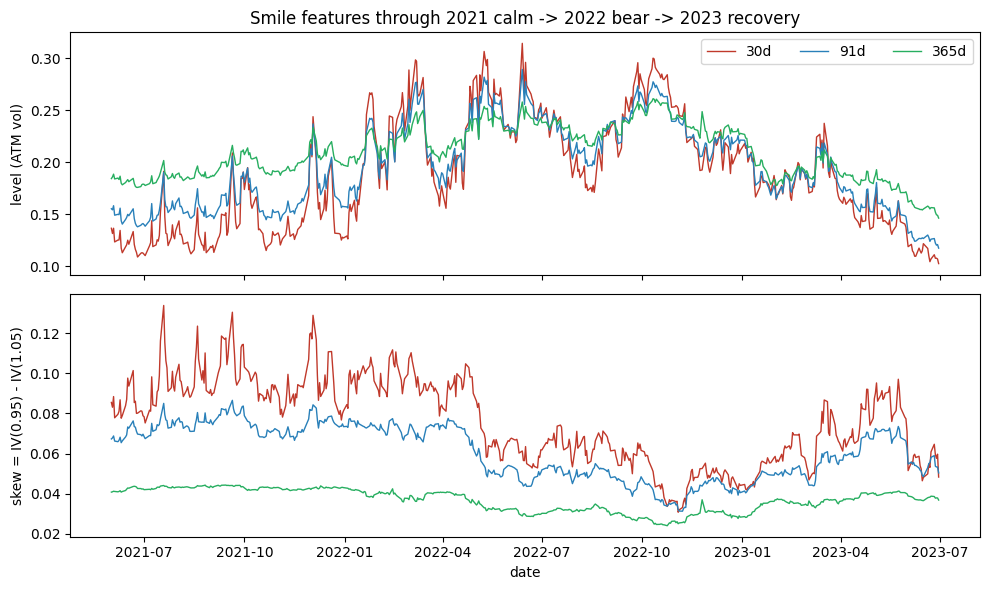

In [2]:
mi = {m: j for j, m in enumerate(MONEY)}
DLNK = np.log(1.05 / 0.95)                       # log-moneyness gap between the two skew pillars

cols = {}
for i, Td in enumerate(MATS):
    iv95, atmv, iv105 = cube[:, i, mi[0.95]], cube[:, i, mi[1.0]], cube[:, i, mi[1.05]]
    cols[(Td, 'level')] = atmv
    cols[(Td, 'skew')]  = iv95 - iv105
    cols[(Td, 'slope')] = (iv105 - iv95) / DLNK
    cols[(Td, 'curv')]  = iv95 + iv105 - 2 * atmv
feat = pd.DataFrame(cols, index=dates)

summ = pd.DataFrame({stat: [feat[(Td, stat)].mean() for Td in MATS]
                     for stat in ['level', 'skew', 'slope', 'curv']}, index=MATS)
summ.index.name = 'tenor_d'
print('sample means of smile features by tenor:')
print(summ.round(4))

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for Td, c in [(30, '#C0392B'), (91, '#2980B9'), (365, '#27AE60')]:
    ax[0].plot(dates, feat[(Td, 'level')], lw=1, color=c, label=f'{Td}d')
    ax[1].plot(dates, feat[(Td, 'skew')], lw=1, color=c, label=f'{Td}d')
ax[0].set_ylabel('level (ATM vol)'); ax[0].legend(ncol=3)
ax[0].set_title('Smile features through 2021 calm -> 2022 bear -> 2023 recovery')
ax[1].set_ylabel('skew = IV(0.95) - IV(1.05)'); ax[1].set_xlabel('date')
plt.tight_layout(); plt.show()

## 2. Sticky strike vs sticky delta: the skew-stickiness ratio (SSR)

These are competing hypotheses about how the smile **moves** when the underlying moves — they cannot be read off a single day's surface, only from the panel:

- **Sticky delta**: the smile is pinned to moneyness (K/F). When F moves, ATM vol doesn't change. Our surfaces are stored in moneyness coordinates, so this predicts *zero* correlation between ATM vol changes and forward returns.
- **Sticky strike**: the IV of each fixed *strike* stays put, so as F moves, the ATM point slides along the smile — ATM vol changes by (skew slope) × (forward return).
- **Stochastic-vol dynamics**: vol and spot are negatively correlated *on top of* the sliding effect — ATM vol moves by roughly *twice* the slope at short tenors.

The one-number test is the **skew-stickiness ratio**:

$$\text{SSR} = \frac{\beta\ \text{from regressing}\ \Delta\sigma_{ATM}\ \text{on}\ \Delta\ln F}{\text{average skew slope}\ \partial\sigma/\partial\ln K}
\qquad 0 = \text{sticky delta},\quad 1 = \text{sticky strike},\quad \approx 2 = \text{stoch-vol limit}$$

For the forward return we use a constant-maturity 30d forward, log-interpolated each day from that day's parity forwards (the day-over-day carry change is negligible next to ~1% daily moves).

          beta  reg_R2  avg_slope    SSR
tenor_d                                 
30      -0.992   0.658     -0.760  1.305
60      -0.797   0.707     -0.673  1.184
91      -0.684   0.728     -0.606  1.128
122     -0.606   0.740     -0.555  1.092
182     -0.506   0.758     -0.482  1.049
273     -0.420   0.774     -0.417  1.006
365     -0.352   0.700     -0.367  0.959


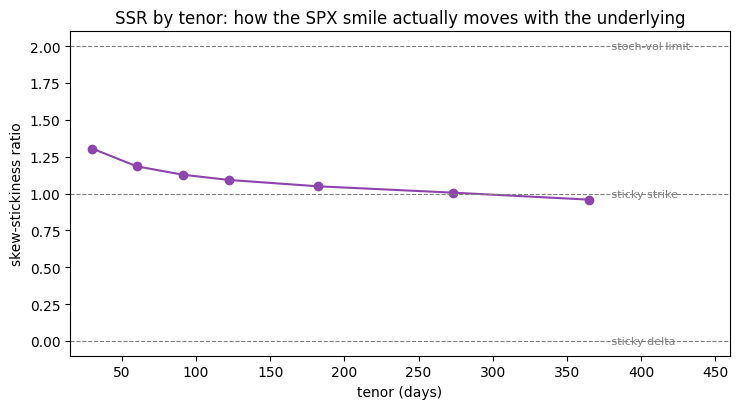

In [3]:
# constant-maturity 30d forward from each day's parity forwards
t30 = 30 / 365.25
rows = []
for f in sorted(glob.glob(f'{IV}/iv_*.parquet')):
    d = pd.read_parquet(f, columns=['T', 'F']).drop_duplicates('T').sort_values('T')
    rows.append({'date': pd.Timestamp(os.path.basename(f)[3:13]),
                 'lnF30': np.interp(t30, d['T'].values, np.log(d['F'].values))})
lnF30 = pd.DataFrame(rows).set_index('date')['lnF30'].reindex(dates)
dlnF = lnF30.diff()

res = []
for Td in MATS:
    datm = feat[(Td, 'level')].diff()
    ok = datm.notna() & dlnF.notna()
    x, y = dlnF[ok].values, datm[ok].values
    beta = np.polyfit(x, y, 1)[0]                    # d(ATM vol) / d(ln F)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    slope_bar = feat[(Td, 'slope')].mean()           # average d(IV)/d(ln K), negative for SPX
    res.append({'tenor_d': Td, 'beta': beta, 'reg_R2': r2,
                'avg_slope': slope_bar, 'SSR': beta / slope_bar})
ssr = pd.DataFrame(res).set_index('tenor_d')
print(ssr.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(ssr.index, ssr['SSR'], 'o-', color='#8E44AD', lw=1.5)
for v, lab in [(0, 'sticky delta'), (1, 'sticky strike'), (2, 'stoch-vol limit')]:
    ax.axhline(v, ls='--', lw=0.8, color='gray')
    ax.text(378, v, f' {lab}', va='center', fontsize=8, color='gray')
ax.set_xlim(15, 460)
ax.set_xlabel('tenor (days)'); ax.set_ylabel('skew-stickiness ratio')
ax.set_title('SSR by tenor: how the SPX smile actually moves with the underlying')
plt.tight_layout(); plt.show()

## 3. PCA baseline: the three classic linear factors

Cont & da Fonseca (2002) showed IV surface variation is dominated by ~3 **linear** factors: a parallel **level** shift, a **term-structure** tilt, and a **moneyness skew** tilt. If that holds here, the first 3 PCs should explain ~99% of variance and their loadings (shown as 7×9 heatmaps) should look like exactly those three patterns. This is the benchmark any nonlinear method has to beat.

explained variance: PC1 93.3%   PC2 4.1%   PC3 1.6%   (first 3 cumulative: 99.0%)


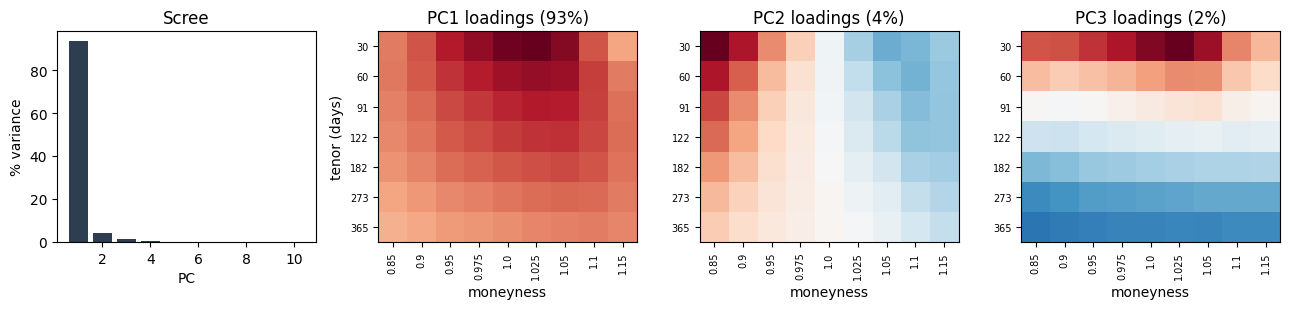

In [4]:
from sklearn.decomposition import PCA

X = S.values - S.values.mean(axis=0)             # demeaned, kept in vol units
pca = PCA(n_components=10).fit(X)
evr = pca.explained_variance_ratio_
print(f'explained variance: PC1 {evr[0]:.1%}   PC2 {evr[1]:.1%}   PC3 {evr[2]:.1%}'
      f'   (first 3 cumulative: {evr[:3].sum():.1%})')

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
axes[0].bar(range(1, 11), evr * 100, color='#2C3E50')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('% variance'); axes[0].set_title('Scree')
for k in range(3):
    L = pca.components_[k].reshape(len(MATS), len(MONEY))
    axes[k + 1].imshow(L, aspect='auto', cmap='RdBu_r', vmin=-np.abs(L).max(), vmax=np.abs(L).max())
    axes[k + 1].set_title(f'PC{k + 1} loadings ({evr[k]:.0%})')
    axes[k + 1].set_xticks(range(len(MONEY))); axes[k + 1].set_xticklabels(MONEY, rotation=90, fontsize=7)
    axes[k + 1].set_yticks(range(len(MATS))); axes[k + 1].set_yticklabels(MATS, fontsize=7)
    axes[k + 1].set_xlabel('moneyness')
axes[1].set_ylabel('tenor (days)')
plt.tight_layout(); plt.show()

## 4. ISOMAP vs PCA: is there nonlinear structure in the skew dynamics?

Earlier notebooks (`DS4FE_IV_Surface_DimReduction`, `DS4FE_IV_Surface_Representation_Test`) found no nonlinear edge in overall variance terms. Here we target the two places nonlinearity is *supposed* to live:

- **Level–skew coupling**: empirically, when vol rises the smile reshapes — level and skew co-move along a *curved* path, which PCA must spend 2–3 linear axes to describe but a manifold method could parameterize with fewer coordinates.
- **Regime hysteresis**: vol spikes fast and decays slow, so stress-on and stress-off may trace *different* paths — a loop in state space, visible in an embedding colored by time.

Three checks: (1) **linear-decode R²** — reconstruct all 63 grid IVs from k embedding coordinates, ISOMAP vs PCA at the same k; (2) **interpretability** — correlate ISOMAP coordinates with level / term-slope / skew to see if it found anything besides the linear factors; (3) **the pictures** — PC1–PC2, ISOMAP 1–2, and the raw level-vs-skew plane, all colored by time, to look for the coupling curve and hysteresis loop directly.

linear-decode R^2 (reconstruct all 63 grid IVs from k coordinates):
  k=1:   ISOMAP 0.928   PCA 0.933
  k=2:   ISOMAP 0.967   PCA 0.975
  k=3:   ISOMAP 0.978   PCA 0.990

correlation of ISOMAP coordinates with the interpretable drivers:
                       ISO1  ISO2  ISO3
level (91d ATM)        1.00  0.04 -0.02
term slope (365d-30d) -0.87  0.07  0.36
skew (30d)            -0.36  0.83 -0.06


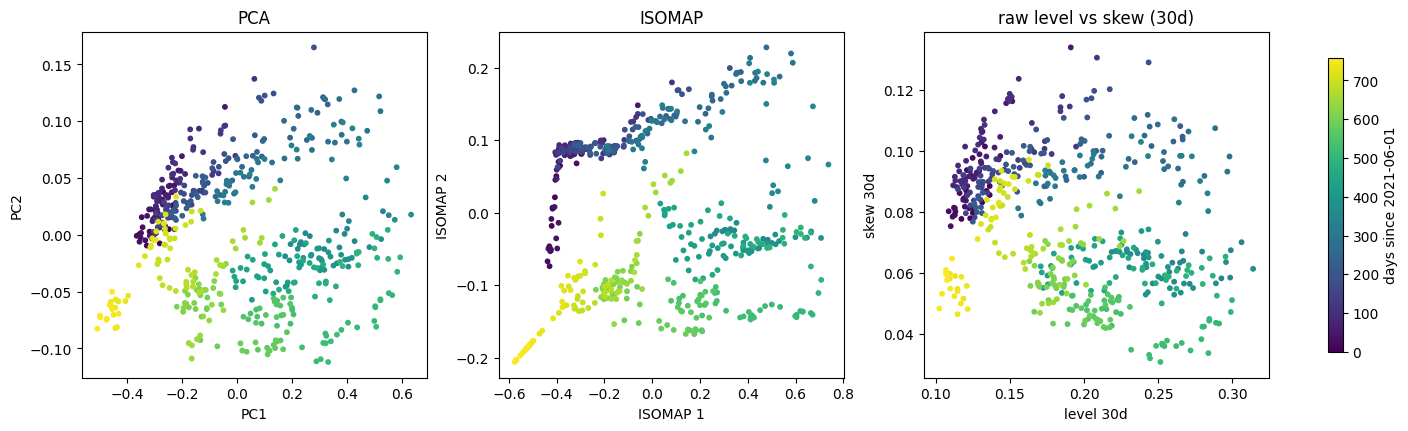

In [5]:
from sklearn.manifold import Isomap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Z = Isomap(n_neighbors=10, n_components=3).fit_transform(X)
P = pca.transform(X)[:, :3]

print('linear-decode R^2 (reconstruct all 63 grid IVs from k coordinates):')
for k in [1, 2, 3]:
    r2_iso = r2_score(X, LinearRegression().fit(Z[:, :k], X).predict(Z[:, :k]),
                      multioutput='variance_weighted')
    print(f'  k={k}:   ISOMAP {r2_iso:.3f}   PCA {evr[:k].sum():.3f}')

drivers = pd.DataFrame({'level (91d ATM)': feat[(91, 'level')],
                        'term slope (365d-30d)': feat[(365, 'level')] - feat[(30, 'level')],
                        'skew (30d)': feat[(30, 'skew')]}, index=dates)
cm = pd.DataFrame({f'ISO{k + 1}': [np.corrcoef(Z[:, k], drivers[c])[0, 1] for c in drivers]
                   for k in range(3)}, index=drivers.columns)
print('\ncorrelation of ISOMAP coordinates with the interpretable drivers:')
print(cm.round(2))

tnum = (dates - dates[0]).days
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ax_, xv, yv, xl, yl, ti in [
        (axes[0], P[:, 0], P[:, 1], 'PC1', 'PC2', 'PCA'),
        (axes[1], Z[:, 0], Z[:, 1], 'ISOMAP 1', 'ISOMAP 2', 'ISOMAP'),
        (axes[2], feat[(30, 'level')], feat[(30, 'skew')], 'level 30d', 'skew 30d', 'raw level vs skew (30d)')]:
    sc = ax_.scatter(xv, yv, c=tnum, cmap='viridis', s=10)
    ax_.set_xlabel(xl); ax_.set_ylabel(yl); ax_.set_title(ti)
fig.colorbar(sc, ax=axes, label='days since 2021-06-01', shrink=0.85)
plt.show()

## Findings

**1. The skew is real, big, and decays with tenor.** Average skew (`IV(0.95) − IV(1.05)`) runs from **7.6 vol points at 30d to 3.7 at 365d**; curvature is concentrated at the short end (1.4 vol pts at 30d, ~0 at 1y). The 2022 bear market shows up as the level regime shift; the skew series is much choppier than the level.

**2. SPX is *not* sticky-delta — it sits between sticky-strike and the stoch-vol limit.** The SSR declines monotonically from **1.31 at 30d to 0.96 at 365d**, with regression R² of 0.66–0.77 (forward returns explain most of daily ATM-vol changes). Reading: short-dated smiles over-react to spot moves (beyond just sliding along the smile, vol itself rises when spot falls — the leverage effect), while 1-year smiles behave almost exactly sticky-strike. The ordering and range match the stochastic-vol literature (SSR ∈ (1, 2), decreasing in tenor).

**3. The linear factor model is confirmed — again.** PC1/PC2/PC3 = **93.3% / 4.1% / 1.6% (99.0% cumulative)**, with loadings that are exactly level / term-tilt / skew-tilt (Cont & da Fonseca).

**4. ISOMAP finds nothing PCA doesn't.** Linear-decode R² is *below* PCA at every k (k=1: 0.928 vs 0.933; k=3: 0.978 vs 0.990) — geodesic coordinates are slightly *lossier*, not better. And the interpretation table says why: **ISO1 correlates 1.00 with the level**, ISO2 0.83 with the skew — ISOMAP just rediscovered the linear factors. The level–skew coupling and the 2022 regime loop are visible in the *raw feature plane* (right panel) but they live in a nearly **flat** 2-plane, so PCA already parameterizes them; curvature of the manifold is too mild for geodesics to pay off.

**Bottom line:** the surface panel supports rich *economics* (strong skew term structure, SSR ≈ 1.3 → 1.0) but its *geometry* is linear — consistent with the LOB findings: for these objects, PCA is the right tool, and the interesting structure is in the dynamics (SSR, regimes), not in manifold curvature.